Importando a base de dados:

In [2]:
import os

print(os.listdir('.'))

['.git', '.gitignore', 'Classification.ipynb', 'LICENSE', 'README.md', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [1]:
import pandas as pd

dados = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

dados

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Análise Exploratória dos Dados

In [4]:
dados.shape

(7043, 21)

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
dados[dados.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [7]:
dados.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
dados.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Não há dados duplicados, "null" ou "nan" presente na base de dados.

In [37]:
colunas = dados.columns

for i, coluna in enumerate(colunas):
    print(f'{i+1}. {coluna}: {dados[coluna].unique()}, ({len(dados[coluna].unique())})')


1. customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'], (7043)
2. gender: ['Female' 'Male'], (2)
3. SeniorCitizen: [0 1], (2)
4. Partner: ['Yes' 'No'], (2)
5. Dependents: ['No' 'Yes'], (2)
6. tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], (73)
7. PhoneService: ['No' 'Yes'], (2)
8. MultipleLines: ['No phone service' 'No' 'Yes'], (3)
9. InternetService: ['DSL' 'Fiber optic' 'No'], (3)
10. OnlineSecurity: ['No' 'Yes' 'No internet service'], (3)
11. OnlineBackup: ['Yes' 'No' 'No internet service'], (3)
12. DeviceProtection: ['No' 'Yes' 'No internet service'], (3)
13. TechSupport: ['No' 'Yes' 'No internet service'], (3)
14. StreamingTV: ['No' 'Yes' 'No internet service'], (3)
15. StreamingMovies: ['No' 'Yes' 'No internet service'], (3)
16. Contract: ['Month-to-mon

In [39]:
dados['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [38]:
dados['TotalCharges'] = pd.to_numeric(dados['TotalCharges'], errors = 'coerce')

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
dados[dados['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
indices_nan = dados[dados['TotalCharges'].isna()].index
indices_nan

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

Observa-se como padrão na base de dados, que os clientes começam a pagar depois do primeiro mês de serviço. Sendo assim, serão substituídos esses valores "NaN" da coluna "TotalCharges" por "0".

In [40]:
dados['TotalCharges'] = dados['TotalCharges'].fillna(0)

dados.loc[indices_nan]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [ ]:
dados[dados['TotalCharges'] == ' ']

<function matplotlib.pyplot.show(close=None, block=None)>

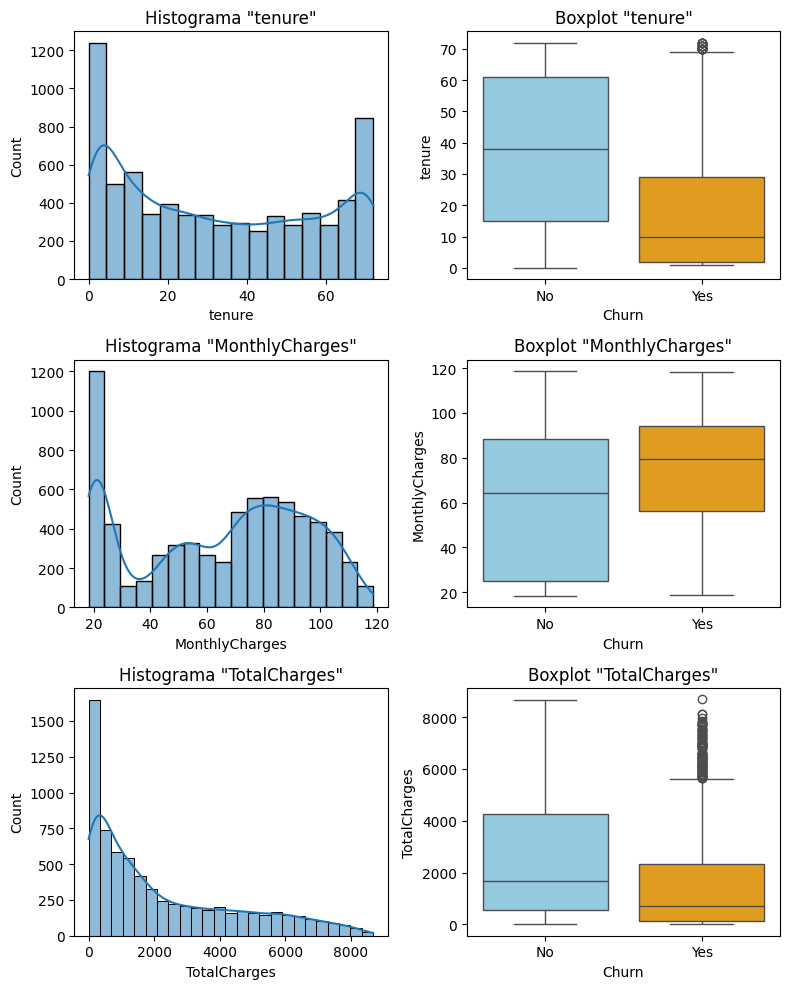

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (8, 10))

for i, coluna in enumerate(cols_num):
    axes[i, 0].set_title(f'Histograma \"{coluna}\"')
    sns.histplot(dados[coluna], kde = True, ax = axes[i, 0])
    axes[i, 1].set_title(f'Boxplot \"{coluna}\"')
    sns.boxplot(data = dados, y = coluna, x = 'Churn', palette = ['skyblue', 'orange'], hue = 'Churn', legend = False, ax = axes[i, 1])

plt.tight_layout()
plt.show


In [18]:
import plotly.express as px

fig = px.scatter_3d(dados, x = 'MonthlyCharges', y = 'tenure', z = 'TotalCharges', color='Churn', 
                    color_discrete_map = {'Yes': 'Orange','No': 'skyblue'},
                    title = 'Gráfico de dispersão de Rotatividade (Churn)')

fig.update_layout(width = 1000, height = 1000)

fig.show()

In [3]:
import phik

#Preparando dados
ddos = dados.copy()

ddos = ddos.drop('customerID', axis = 1)
ddos['TotalCharges'] = pd.to_numeric(ddos['TotalCharges'], errors = 'coerce')
ddos['TotalCharges'] = ddos['TotalCharges'].fillna(0)

matriz_corr = ddos.phik_matrix()

matriz_corr

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009025,0.000000,0.000000
SeniorCitizen,0.000000,1.000000,0.016992,0.324576,0.028663,0.000000,0.087925,0.160702,0.127319,0.109995,0.110177,0.135283,0.111714,0.113778,0.086231,0.242133,0.292725,0.304691,0.149384,0.233432
Partner,0.000000,0.016992,1.000000,0.652122,0.491658,0.019540,0.086249,0.000000,0.091202,0.092012,0.100092,0.076326,0.082251,0.077506,0.179736,0.013218,0.243008,0.203237,0.424467,0.232930
Dependents,0.000000,0.324576,0.652122,1.000000,0.212209,0.000000,0.011198,0.108463,0.117219,0.097766,0.094597,0.109753,0.088193,0.084684,0.147680,0.172593,0.224903,0.184213,0.119077,0.253936
tenure,0.000000,0.028663,0.491658,0.212209,1.000000,0.000000,0.374604,0.019357,0.365936,0.401085,0.401463,0.363817,0.321011,0.331299,0.664660,0.000000,0.375115,0.411002,0.842146,0.474001
PhoneService,0.000000,0.000000,0.019540,0.000000,0.000000,1.000000,1.000000,0.278954,0.106021,0.103910,0.103604,0.106451,0.108565,0.106784,0.000000,0.016811,0.000000,0.831362,0.198660,0.000000
MultipleLines,0.000000,0.087925,0.086249,0.011198,0.374604,1.000000,1.000000,0.739808,0.540261,0.562933,0.564610,0.541088,0.586049,0.586815,0.244410,0.099953,0.174849,0.710101,0.493936,0.021922
InternetService,0.000000,0.160702,0.000000,0.108463,0.019357,0.278954,0.739808,1.000000,0.949498,0.942842,0.942811,0.948914,0.946713,0.946294,0.505187,0.231438,0.323886,0.918980,0.508222,0.196202
OnlineSecurity,0.001460,0.127319,0.091202,0.117219,0.365936,0.106021,0.540261,0.949498,1.000000,0.947224,0.946787,0.952651,0.943082,0.943248,0.636884,0.208320,0.315799,0.812633,0.529684,0.211840
OnlineBackup,0.000000,0.109995,0.092012,0.097766,0.401085,0.103910,0.562933,0.942842,0.947224,1.000000,0.947487,0.947756,0.945789,0.945395,0.581660,0.195321,0.293413,0.818858,0.567762,0.177422


In [4]:
for coluna in list(ddos.columns):
    if ddos[coluna].dtype == 'object' and len(ddos[coluna].unique()) == 2:
        ddos[coluna] = ddos[coluna].replace({'No': 0, 'Yes': 1}).infer_objects(copy=False)

ddos['gender'] = ddos['gender'].map({'Male': 0, 'Female': 1})

ddos

C:\Users\mayma\AppData\Local\Temp\ipykernel_6920\3126155883.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ddos[coluna] = ddos[coluna].replace({'No': 0, 'Yes': 1}).infer_objects(copy=False)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50,0
7039,1,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,0
7040,1,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,0,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.60,1


In [89]:
ddos.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
for i, coluna in enumerate(list(ddos.columns)):
    print(f'{i+1}. {coluna}: {ddos[coluna].unique()}, ({len(ddos[coluna].unique())})')

1. gender: [1 0], (2)
2. SeniorCitizen: [0 1], (2)
3. Partner: [1 0], (2)
4. Dependents: [0 1], (2)
5. tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], (73)
6. PhoneService: [0 1], (2)
7. MultipleLines: ['No phone service' 'No' 'Yes'], (3)
8. InternetService: ['DSL' 'Fiber optic' 'No'], (3)
9. OnlineSecurity: ['No' 'Yes' 'No internet service'], (3)
10. OnlineBackup: ['Yes' 'No' 'No internet service'], (3)
11. DeviceProtection: ['No' 'Yes' 'No internet service'], (3)
12. TechSupport: ['No' 'Yes' 'No internet service'], (3)
13. StreamingTV: ['No' 'Yes' 'No internet service'], (3)
14. StreamingMovies: ['No' 'Yes' 'No internet service'], (3)
15. Contract: ['Month-to-month' 'One year' 'Two year'], (3)
16. PaperlessBilling: [1 0], (2)
17. PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automat

In [11]:
from scipy import stats

cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

variaveis_num = ddos[cols_num]

resultados_corr = []

for var in list(variaveis_num.columns):
    corr_num, p_valor = stats.pointbiserialr(variaveis_num[var], ddos['Churn'])
    resultados_corr.append({'Variável': var,
                            'Correlação': corr_num,
                            'p-valor': p_valor})
    
df_corr_num = pd.DataFrame(resultados_corr).sort_values(by = 'Correlação', ascending = False)

df_corr_num

,Variável,Correlação,p-valor
1,MonthlyCharges,0.193356,2.706646e-60
2,TotalCharges,-0.198324,2.127212e-63
0,tenure,-0.352229,7.999058e-205


In [12]:
col_obj = []

for col in list(ddos.columns):
    if ddos[col].dtype == 'object':
        col_obj.append(col)

col_obj

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [102]:
colunas_dum = 0
for col in list(ddos.columns):
    if ddos[col].dtype == 'object':
        colunas_dum += len(ddos[col].unique())

conta = 10 + colunas_dum

print(conta)



41


In [13]:
ddos = pd.get_dummies(ddos, columns = col_obj, drop_first = False, dtype = int)

ddos

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,...,0,0,1,0,1,0,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,0,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,...,1,0,0,1,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,...,1,0,0,1,0,0,0,0,0,1


In [14]:
for i, coluna in enumerate(list(ddos.columns)):
    print(f'{i+1}. {coluna}: {ddos[coluna].unique()}, ({len(ddos[coluna].unique())})')

1. gender: [1 0], (2)
2. SeniorCitizen: [0 1], (2)
3. Partner: [1 0], (2)
4. Dependents: [0 1], (2)
5. tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], (73)
6. PhoneService: [0 1], (2)
7. PaperlessBilling: [1 0], (2)
8. MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ], (1585)
9. TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ], (6531)
10. Churn: [0 1], (2)
11. MultipleLines_No: [0 1], (2)
12. MultipleLines_No phone service: [1 0], (2)
13. MultipleLines_Yes: [0 1], (2)
14. InternetService_DSL: [1 0], (2)
15. InternetService_Fiber optic: [0 1], (2)
16. InternetService_No: [0 1], (2)
17. OnlineSecurity_No: [1 0], (2)
18. OnlineSecurity_No internet service: [0 1], (2)
19. OnlineSecurity_Yes: [0 1], (2)
20. OnlineBackup_No: [0 1], (2)
21. OnlineBackup_No internet service: [0 1], (2)

In [15]:
corr = ddos.corr(method = 'pearson', min_periods = 1)

corr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.000000,0.001874,0.001808,-0.010517,-0.005106,0.006488,0.011754,0.014569,0.000080,0.008612,...,-0.005374,-0.006026,0.010487,0.003386,-0.008026,0.003695,0.016024,-0.001215,-0.000752,-0.013744
SeniorCitizen,0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.103006,0.150889,...,0.034210,-0.182742,0.120176,0.138360,-0.046262,-0.117000,-0.016159,-0.024135,0.171718,-0.153477
Partner,0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.317504,-0.150448,...,-0.117529,0.000615,0.117412,-0.280865,0.082783,0.248091,0.110706,0.082029,-0.083852,-0.095125
Dependents,-0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.062078,-0.164221,...,-0.078198,0.139812,-0.039741,-0.231720,0.068368,0.204613,0.052021,0.060267,-0.150642,0.059071
tenure,-0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.826178,-0.352229,...,-0.252220,-0.039062,0.286111,-0.645561,0.202570,0.558533,0.243510,0.233006,-0.208363,-0.233852
PhoneService,0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113214,0.011942,...,-0.112254,0.172209,-0.032959,-0.000742,-0.002791,0.003519,0.007556,-0.007721,0.003062,-0.003319
PaperlessBilling,0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158574,0.191825,...,0.059488,-0.321013,0.211716,0.169096,-0.051391,-0.147889,-0.016332,-0.013589,0.208865,-0.205398
MonthlyCharges,0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651174,0.193356,...,0.018075,-0.763557,0.627429,0.060165,0.004904,-0.074681,0.042812,0.030550,0.271625,-0.377437
TotalCharges,0.000080,0.103006,0.317504,0.062078,0.826178,0.113214,0.158574,0.651174,1.000000,-0.198324,...,-0.202188,-0.375223,0.520122,-0.444255,0.170814,0.354481,0.185987,0.182915,-0.059246,-0.295758
Churn,0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.198324,1.000000,...,0.130845,-0.227890,0.061382,0.405103,-0.177820,-0.302253,-0.117937,-0.134302,0.301919,-0.091683


Pesquisar melhor como funciona a biblioteca de correlação philk, aproveitar e aplicar alguns métodos específicos de correlação à mão (Cramer's V, Pearson) para verificar se a biblioteca philk tem resultados consistentes.

Análise de correlação entre as variáveis numéricas e rotatividade (Churn - Binária)